# Week 2 In-Class Exercise: End-to-End Machine Learning Project

In the textbook (Chapter 2), we built an end-to-end ML pipeline to predict **median house values** in California.

In this exercise, you'll build a similar pipeline to answer:

> **Can we predict a country's life expectancy from its healthcare spending, economic, and demographic indicators?**

You'll follow the same workflow:
1. Get the Data
2. Explore the Data (EDA)
3. Prepare the Data for ML
4. Select and Train Models
5. Fine-Tune with Cross-Validation
6. Evaluate on Test Set

**Data source:** [World Bank Open Data](https://data.worldbank.org/)

### API References (scikit-learn 1.4)

| Class/Function | Documentation |
|----------------|---------------|
| `train_test_split` | [sklearn.model_selection.train_test_split](https://scikit-learn.org/1.4/modules/generated/sklearn.model_selection.train_test_split.html) |
| `SimpleImputer` | [sklearn.impute.SimpleImputer](https://scikit-learn.org/1.4/modules/generated/sklearn.impute.SimpleImputer.html) |
| `StandardScaler` | [sklearn.preprocessing.StandardScaler](https://scikit-learn.org/1.4/modules/generated/sklearn.preprocessing.StandardScaler.html) |
| `Pipeline` | [sklearn.pipeline.Pipeline](https://scikit-learn.org/1.4/modules/generated/sklearn.pipeline.Pipeline.html) |
| `make_pipeline` | [sklearn.pipeline.make_pipeline](https://scikit-learn.org/1.4/modules/generated/sklearn.pipeline.make_pipeline.html) |
| `ColumnTransformer` | [sklearn.compose.ColumnTransformer](https://scikit-learn.org/1.4/modules/generated/sklearn.compose.ColumnTransformer.html) |
| `LinearRegression` | [sklearn.linear_model.LinearRegression](https://scikit-learn.org/1.4/modules/generated/sklearn.linear_model.LinearRegression.html) |
| `DecisionTreeRegressor` | [sklearn.tree.DecisionTreeRegressor](https://scikit-learn.org/1.4/modules/generated/sklearn.tree.DecisionTreeRegressor.html) |
| `RandomForestRegressor` | [sklearn.ensemble.RandomForestRegressor](https://scikit-learn.org/1.4/modules/generated/sklearn.ensemble.RandomForestRegressor.html) |
| `cross_val_score` | [sklearn.model_selection.cross_val_score](https://scikit-learn.org/1.4/modules/generated/sklearn.model_selection.cross_val_score.html) |
| `GridSearchCV` | [sklearn.model_selection.GridSearchCV](https://scikit-learn.org/1.4/modules/generated/sklearn.model_selection.GridSearchCV.html) |
| `mean_squared_error` | [sklearn.metrics.mean_squared_error](https://scikit-learn.org/1.4/modules/generated/sklearn.metrics.mean_squared_error.html) |
| Pandas DataFrame | [pandas.DataFrame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) |
| NumPy | [numpy.org/doc](https://numpy.org/doc/stable/reference/) |

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/pjmcswee/IST707-Notebooks/blob/main/week2/week2_inclass_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

## Setup

Run this cell to import all necessary libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## Step 1: Get the Data

We fetch country-level indicators from the World Bank API:
- **SP.DYN.LE00.IN** — Life expectancy at birth (TARGET)
- **SH.XPD.CHEX.PC.CD** — Health expenditure per capita (US$)
- **NY.GDP.PCAP.CD** — GDP per capita (US$)
- **SP.POP.TOTL** — Total population
- **SE.XPD.TOTL.GD.ZS** — Government expenditure on education (% GDP)
- **SH.MED.PHYS.ZS** — Physicians per 1,000 people

This cell is provided — just run it.

In [2]:
import urllib.request
import json

def fetch_world_bank_indicator(indicator, date_range="2018:2022"):
    """Fetch most recent value per country from World Bank API."""
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator}?date={date_range}&format=json&per_page=2000"
    with urllib.request.urlopen(url) as resp:
        data = json.loads(resp.read())
    # Get country list to filter aggregates
    url_c = "https://api.worldbank.org/v2/country?per_page=400&format=json"
    with urllib.request.urlopen(url_c) as resp:
        countries = json.loads(resp.read())
    country_codes = {c['id'] for c in countries[1] if c['region']['id'] != 'NA'}
    # Most recent non-null value per country
    result = {}
    for record in data[1]:
        code = record['countryiso3code']
        if record['value'] is not None and code in country_codes and code not in result:
            result[code] = {'country': record['country']['value'], 'value': record['value']}
    return result

print("Fetching World Bank data (this may take a moment)...")
indicators = {
    'life_expectancy': 'SP.DYN.LE00.IN',
    'health_spending_pc': 'SH.XPD.CHEX.PC.CD',
    'gdp_per_capita': 'NY.GDP.PCAP.CD',
    'population': 'SP.POP.TOTL',
    'edu_spending_pct_gdp': 'SE.XPD.TOTL.GD.ZS',
    'physicians_per_1000': 'SH.MED.PHYS.ZS',
}

raw_data = {}
for name, code in indicators.items():
    print(f"  Fetching {name}...")
    raw_data[name] = fetch_world_bank_indicator(code)

# Merge into a single DataFrame
all_codes = set()
for d in raw_data.values():
    all_codes.update(d.keys())

rows = []
for code in all_codes:
    if code in raw_data['life_expectancy'] and code in raw_data['health_spending_pc']:
        row = {'country': raw_data['life_expectancy'][code]['country']}
        for name in indicators:
            row[name] = raw_data[name][code]['value'] if code in raw_data[name] else None
        rows.append(row)

df = pd.DataFrame(rows)
print(f"\nDataset loaded: {len(df)} countries, {len(df.columns)} features")
df.head()

Fetching World Bank data (this may take a moment)...
  Fetching life_expectancy...
  Fetching health_spending_pc...
  Fetching gdp_per_capita...
  Fetching population...
  Fetching edu_spending_pct_gdp...
  Fetching physicians_per_1000...

Dataset loaded: 193 countries, 7 features


,country,life_expectancy,health_spending_pc,gdp_per_capita,population,edu_spending_pct_gdp,physicians_per_1000
0,Central African Republic,18.818,47.915234,467.359825,5098039,2.115091,0.029
1,Jordan,77.088,334.387146,4754.413622,11256263,3.153000,2.851
2,Cote d'Ivoire,61.562,84.899155,2333.371283,30395002,3.474850,0.162
3,Monaco,85.746,7674.098145,226052.060665,38931,1.171060,8.609
4,Panama,79.324,1572.930176,17378.607008,4400773,3.377810,1.625


## Step 2: Explore the Data

Let's examine the dataset — run these cells to understand the data.

In [3]:
df.info()
print("\n")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               193 non-null    object 
 1   life_expectancy       193 non-null    float64
 2   health_spending_pc    193 non-null    float64
 3   gdp_per_capita        191 non-null    float64
 4   population            193 non-null    int64  
 5   edu_spending_pct_gdp  173 non-null    float64
 6   physicians_per_1000   178 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.7+ KB




,life_expectancy,health_spending_pc,gdp_per_capita,population,edu_spending_pct_gdp,physicians_per_1000
count,193.000000,193.000000,191.000000,1.930000e+02,173.000000,178.000000
mean,72.387485,1361.103912,18438.282684,4.105772e+07,4.370138,2.094921
std,8.047729,2211.409457,30154.858839,1.495276e+08,2.120896,1.845635
min,18.818000,15.858092,301.832256,9.992000e+03,0.000007,0.028000
25%,67.368000,96.748642,2366.493427,2.105529e+06,3.046890,0.411250
50%,73.254000,445.104736,6571.974455,9.041851e+06,4.098658,1.637000
75%,77.575610,1415.795776,20817.598794,3.043726e+07,5.280650,3.448000
max,85.746000,12586.196289,226052.060665,1.425423e+09,14.786031,9.542000


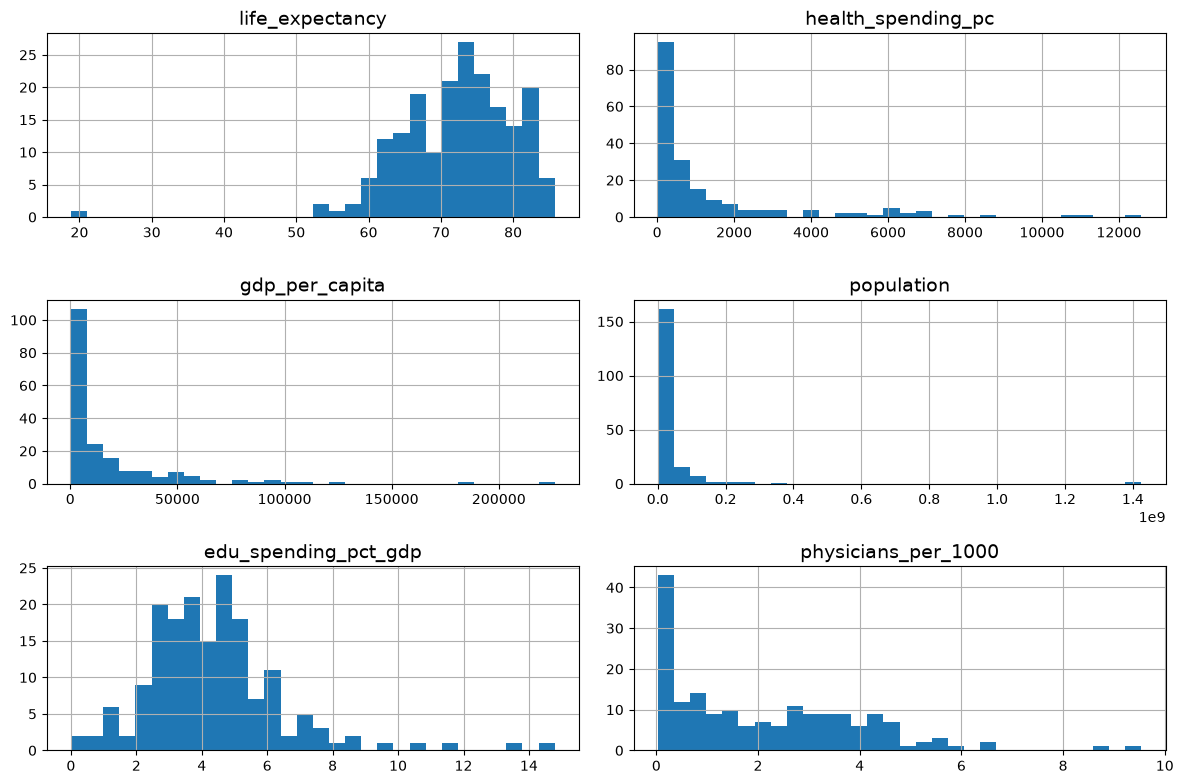

In [4]:
df.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

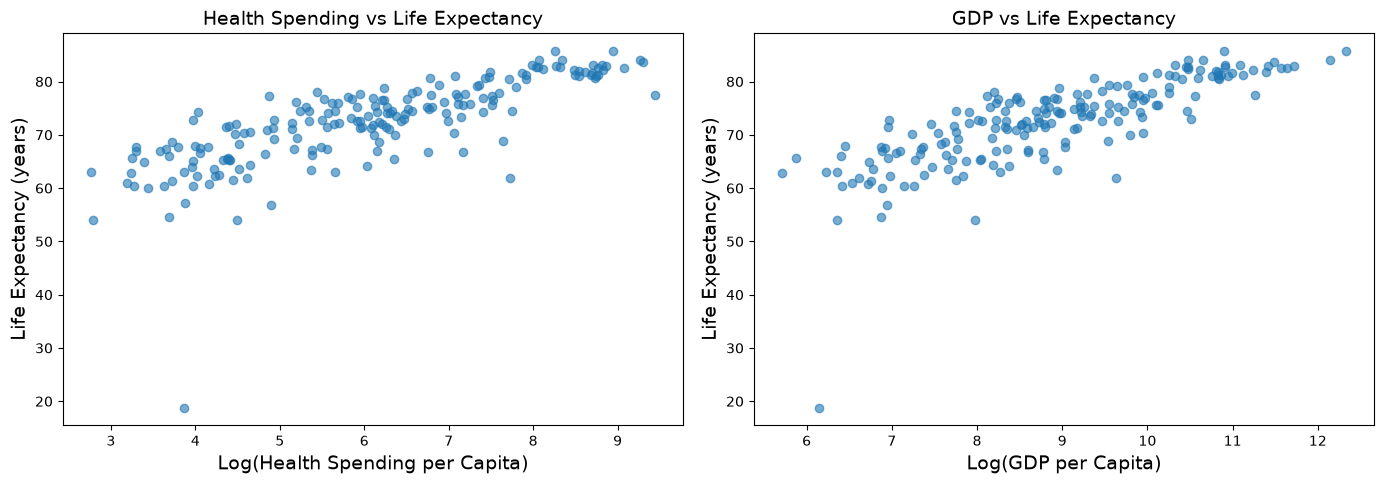

In [5]:
# Log-transform spending for better visualization
df['log_health_spending'] = np.log(df['health_spending_pc'].clip(lower=1))
df['log_gdp_pc'] = np.log(df['gdp_per_capita'].clip(lower=1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['log_health_spending'], df['life_expectancy'], alpha=0.6)
axes[0].set_xlabel('Log(Health Spending per Capita)')
axes[0].set_ylabel('Life Expectancy (years)')
axes[0].set_title('Health Spending vs Life Expectancy')

axes[1].scatter(df['log_gdp_pc'], df['life_expectancy'], alpha=0.6)
axes[1].set_xlabel('Log(GDP per Capita)')
axes[1].set_ylabel('Life Expectancy (years)')
axes[1].set_title('GDP vs Life Expectancy')
plt.tight_layout()
plt.show()

## Step 3: Prepare the Data

### 3a: Separate features and target

In [6]:
# Drop the country name and any log-transformed columns
feature_cols = ['health_spending_pc', 'gdp_per_capita', 'population', 
                'edu_spending_pct_gdp', 'physicians_per_1000']
target_col = 'life_expectancy'

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nMissing values per feature:")
print(X.isnull().sum())

Features shape: (193, 5)
Target shape: (193,)

Missing values per feature:
health_spending_pc       0
gdp_per_capita           2
population               0
edu_spending_pct_gdp    20
physicians_per_1000     15
dtype: int64


### 3b: Split into train and test sets

**Your turn!** Split the data into training (80%) and test (20%) sets.

**Hint:** From the textbook:
```python
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
```

API reference: [train_test_split](https://scikit-learn.org/1.4/modules/generated/sklearn.model_selection.train_test_split.html)

In [7]:
# TODO: Split the data into train and test sets (80/20 split, random_state=42)
# Your code here:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)





### 3c: Build a preprocessing pipeline

**Your turn!** Create a pipeline that:
1. Imputes missing values with the median (using `SimpleImputer`)
2. Scales features with `StandardScaler`

**Hint:** From the textbook:
```python
from sklearn.pipeline import make_pipeline
num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
```

API references: [SimpleImputer](https://scikit-learn.org/1.4/modules/generated/sklearn.impute.SimpleImputer.html) | [StandardScaler](https://scikit-learn.org/1.4/modules/generated/sklearn.preprocessing.StandardScaler.html) | [make_pipeline](https://scikit-learn.org/1.4/modules/generated/sklearn.pipeline.make_pipeline.html)

In [8]:
# TODO: Create a preprocessing pipeline with SimpleImputer and StandardScaler
# Your code here:

from sklearn.pipeline import make_pipeline
num_pipeline = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())




## Step 4: Select and Train Models

**Your turn!** Create full pipelines (preprocessing + model) for:
1. `LinearRegression`
2. `DecisionTreeRegressor`
3. `RandomForestRegressor`

Train each on the training data and compute the training RMSE.

**Hint:** From the textbook:
```python
full_pipeline = make_pipeline(preprocessing, LinearRegression())
full_pipeline.fit(X_train, y_train)
predictions = full_pipeline.predict(X_train)
rmse = root_mean_squared_error(y_train, predictions)
```

API references: [LinearRegression](https://scikit-learn.org/1.4/modules/generated/sklearn.linear_model.LinearRegression.html) | [DecisionTreeRegressor](https://scikit-learn.org/1.4/modules/generated/sklearn.tree.DecisionTreeRegressor.html) | [RandomForestRegressor](https://scikit-learn.org/1.4/modules/generated/sklearn.ensemble.RandomForestRegressor.html)

In [9]:
# TODO: Create and train a Linear Regression pipeline, compute training RMSE
# Your code here:

lr_pipeline = make_pipeline(num_pipeline, LinearRegression())
lr_pipeline.fit(X_train, y_train)
lr_predictions = lr_pipeline.predict(X_train)
lr_rmse = root_mean_squared_error(y_train, lr_predictions)

print(lr_rmse)



5.866042136483425


In [12]:
# TODO: Create and train a Decision Tree pipeline, compute training RMSE
# Your code here:

dt_pipeline = make_pipeline(num_pipeline, DecisionTreeRegressor())
dt_pipeline.fit(X_train, y_train)
dt_predictions = dt_pipeline.predict(X_train)
dt_rmse = root_mean_squared_error(y_train, dt_predictions)

print(dt_rmse)


0.0


In [13]:
# TODO: Create and train a Random Forest pipeline, compute training RMSE
# Your code here:

rf_pipeline = make_pipeline(num_pipeline, RandomForestRegressor())
rf_pipeline.fit(X_train, y_train)
rf_predictions = rf_pipeline.predict(X_train)
rf_rmse = root_mean_squared_error(y_train, rf_predictions)

print(rf_rmse)



2.0263362900385102


**Question:** Which model has the lowest training RMSE? Is that necessarily the best model? Why or why not?

*Your answer:* The decision tree has the lowest RMSE. It has an RMSE of 0.0. That does not necessarily mean it's the best. It is likely overfit, because the RMSE is indicating that it perfectly predicts on the training data, which is means it learned the training data too well and likely cannot generalize to new data.



## Step 5: Fine-Tune with Cross-Validation

**Your turn!** Use `cross_val_score` to evaluate each model with 5-fold cross-validation.

**Hint:** From the textbook:
```python
from sklearn.model_selection import cross_val_score
scores = -cross_val_score(pipeline, X_train, y_train,
                          scoring="neg_root_mean_squared_error", cv=5)
```

API reference: [cross_val_score](https://scikit-learn.org/1.4/modules/generated/sklearn.model_selection.cross_val_score.html)

In [17]:
# TODO: Evaluate all three models with 5-fold cross-validation
# Print mean and std of RMSE for each
# Your code here:
from sklearn.model_selection import cross_val_score

lr_scores = -cross_val_score(lr_pipeline, X_train, y_train, scoring="neg_root_mean_squared_error", cv = 5)
dt_scores = -cross_val_score(dt_pipeline, X_train, y_train, scoring="neg_root_mean_squared_error", cv = 5)
rf_scores = -cross_val_score(rf_pipeline, X_train, y_train, scoring="neg_root_mean_squared_error", cv = 5)

print(f'Logistic Regression RMSEs: {lr_scores}')
print(f'Decision Tree RMSEs: {dt_scores}')
print(f'Random Forest RMSEs: {rf_scores}')


Logistic Regression RMSEs: [4.1952208  9.4901     5.9267893  5.67051609 4.726386  ]
Decision Tree RMSEs: [ 4.0711459   8.08977895  4.49350255 12.99881254  4.05123627]
Random Forest RMSEs: [2.86354441 8.37870163 3.72800881 7.47212839 3.37729171]


**Question:** How do the cross-validation scores compare to the training scores? What does this tell you about overfitting?

*Your answer:* The scores for logisitic regression and random forest are slightly similar to the RMSE of the training data predictions. This means they are likely not overfit. The scores for the decision tree models are significantly higher than the RMSE of the training data prediction for decision tree model, meaning I can confidently conclude that the original model overfit.



## Step 6: Hyperparameter Tuning with GridSearchCV

**Your turn!** Use `GridSearchCV` to tune the Random Forest's `n_estimators` and `max_features`.

**Hint:**
```python
param_grid = [
    {'randomforestregressor__n_estimators': [50, 100, 200],
     'randomforestregressor__max_features': [2, 3, 4]}
]
grid_search = GridSearchCV(pipeline, param_grid, cv=5,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)
```

API reference: [GridSearchCV](https://scikit-learn.org/1.4/modules/generated/sklearn.model_selection.GridSearchCV.html)

In [ ]:
# TODO: Run GridSearchCV on the Random Forest pipeline
# Print best parameters and best score
# Your code here:

param_grid = [
    {'randomforestregressor__n_estimators': [50, 100, 200],
     'randomforestregressor__max_features': [2, 3, 4]}
]

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5,
                           scoring='neg_root_mean_squared_error')

grid_search.fit(X_train, y_train)

print(f'Best Params{grid_search.best_params_}')



Best Params{'randomforestregressor__max_features': 3, 'randomforestregressor__n_estimators': 50}


## Step 7: Evaluate on the Test Set

**Your turn!** Take the best model from GridSearchCV and evaluate it on the test set.

**Hint:**
```python
final_model = grid_search.best_estimator_
final_predictions = final_model.predict(X_test)
final_rmse = root_mean_squared_error(y_test, final_predictions)
```

In [19]:
# TODO: Evaluate the best model on the test set
# Your code here:

final_model = grid_search.best_estimator_

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)

print(final_rmse)

4.082019084388297


## Reflection Questions

Answer each question in the cell below it (2-3 sentences each).

**Q1:** Why did we use a log transformation for visualization but not in the actual pipeline? Could adding log-transformed features improve the model?

*Your answer:* I think we used log transformation for visualization to better display the relationship between variables in our data. I think adding the log-transformed features to the model could improve model performance, because it would standardize the distributions of the vairables to a standard distribution.



**Q2:** The Decision Tree likely achieved 0 training RMSE but poor cross-validation RMSE. Explain why, using the concepts of overfitting and underfitting.

*Your answer:* When the decision tree model had a RMSE of 0, it was overfit. Meaning it learned the training data too well and was unable to generalize on new data. The cross-validation RMSE was technically worse, since it was further from 0, but that actually means the model was not perfectly fit to the training data, meaning it probably would generalize to new data, better than the original decision tree model.




**Q3:** Why is cross-validation essential when comparing models? What would happen if we just used training RMSE?

*Your answer:* It is important to use cross-validation when comparing models to see how the model performs on unseen data, since the validation data is withheld from training. If we just used training RMSE, we would likely conclude more often than not that our models overfit. I'm not confident on this answer, but that's my best guess.



**Q4:** What additional features or data sources could improve predictions? Name at least two and explain why.

*Your answer:* I think a feature that would improve our model is some sort of feature about access to healthcare, even if a country has high health care spending, if not everyone can access it, the health care is less meaningful. Two more features we could add is average income per person, and if healthcare is free or paid for by citizens. That is important because in a country with non-free healthcare, wealthier people are able to access more and better healthcare. While in a country with free healthcare, income would matter less.



In [ ]:
import sys; print(sys.executable); print(sys.version); print(sys.prefix)